In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv('placement.csv')

In [11]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [12]:
df.shape

(100, 4)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.2 KB


In [14]:
# steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output col
# 2. Scale the values
# 3. Train Test Split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [15]:
df = df.iloc[:,1:]

In [16]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


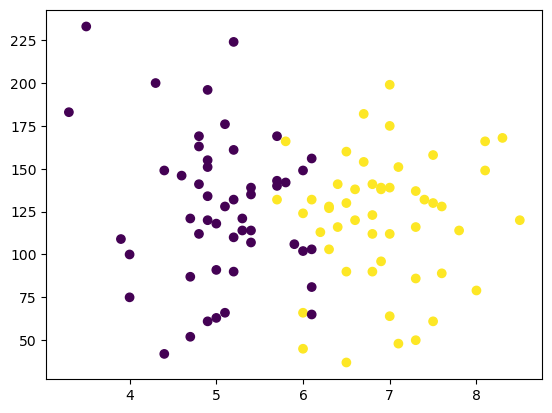

In [19]:
plt.scatter(df['cgpa'],df['iq'],c = df['placement'])

In [20]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [21]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [23]:
y.shape

(100,)

In [24]:
from sklearn.model_selection import train_test_split

In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1,random_state=42)

In [27]:
X_train

,cgpa,iq
18,4.0,100.0
30,7.6,128.0
73,4.9,61.0
33,6.0,149.0
90,7.3,86.0
...,...,...
60,6.9,139.0
71,6.1,132.0
14,6.1,103.0
92,5.2,110.0


In [28]:
y_train

18    0
30    1
73    0
33    0
90    1
     ..
60    1
71    1
14    0
92    0
51    0
Name: placement, Length: 90, dtype: int64

In [29]:
from sklearn.preprocessing import StandardScaler

In [31]:
scaler = StandardScaler()

In [32]:
X_train = scaler.fit_transform(X_train)

In [33]:
X_train

array([[-1.73718527, -0.62029848],
       [ 1.45537303,  0.09806189],
       [-0.9390457 , -1.62087186],
       [ 0.03645823,  0.63683217],
       [ 1.1893265 , -0.97947867],
       [-0.14090612,  0.45724208],
       [-0.9390457 ,  0.79076654],
       [ 1.1893265 , -1.90308486],
       [-0.49563482,  0.3802749 ],
       [-1.82586745, -0.38939693],
       [ 1.63273738, -0.26111829],
       [-1.38245657,  0.63683217],
       [ 0.92327998,  1.91961855],
       [ 1.45537303, -0.90251149],
       [ 2.2535126 , -0.10718393],
       [-0.76168135,  1.32953682],
       [-0.9390457 ,  0.25199626],
       [-1.38245657, -2.10833068],
       [-0.76168135, -1.49259322],
       [ 1.1893265 , -0.20980684],
       [ 0.8345978 ,  0.35461917],
       [-0.67299917,  0.9447009 ],
       [-0.14090612,  1.07297954],
       [-0.67299917, -0.87685576],
       [ 0.74591563, -0.31242975],
       [ 1.01196215, -1.95439632],
       [ 0.8345978 , -0.72292139],
       [ 1.8987839 ,  1.07297954],
       [ 0.74591563,

In [35]:
X_test = scaler.transform(X_test)

In [36]:
X_test

array([[ 1.36669085,  0.14937335],
       [ 2.07614825,  1.124291  ],
       [ 0.30250475,  0.07240616],
       [ 0.03645823, -1.49259322],
       [ 1.36669085, -1.62087186],
       [-1.20509222,  0.55986499],
       [-0.9390457 , -0.10718393],
       [-0.9390457 ,  1.84265137],
       [ 0.03645823, -2.0313635 ],
       [ 0.74591563, -0.03021675]])

In [37]:
from sklearn.linear_model import LogisticRegression

In [38]:
clf = LogisticRegression()

In [39]:
# model training
clf.fit(X_train,y_train)

LogisticRegression()

In [42]:
y_pred = clf.predict(X_test)

In [43]:
y_pred

array([1, 1, 1, 0, 1, 0, 0, 0, 0, 1], dtype=int64)

In [44]:
from sklearn.metrics import accuracy_score

In [45]:
accuracy_score(y_test,y_pred)

0.8

In [50]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

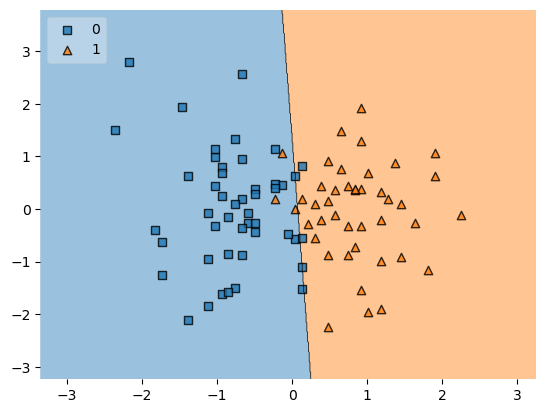

In [53]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [54]:
import pickle

In [55]:
pickle.dump(clf,open('model.pkl','wb'))